<a href="https://colab.research.google.com/github/thisishasan/cbir_system/blob/main/08_train_auto_encoder_subclass_1_100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
%cd '/content/drive/My Drive/01_information_retrieval'
!ls

/content/drive/My Drive/01_information_retrieval
binary_scenario      training_1_200	  training_1_40_subclass
Notes.gdoc	     training_1_200.h5	  training_1_40_subclass.h5
original	     training_1_200.json  training_1_40_subclass.json
reconstruction	     training_1_40	  training_1_indexed_100.json
subclass_scenario    training_1_400	  training_1_indexed_200.json
tflite_model	     training_1_400.h5	  training_1_indexed_400.json
training_1_100	     training_1_400.json  training_1_indexed_40.json
training_1_100.h5    training_1_40.h5
training_1_100.json  training_1_40.json


In [19]:
import matplotlib
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import json

In [20]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import numpy as np

In [21]:
class ConvAutoEncoder:
    @staticmethod
    def build(width, height, depth, filters=(128,), latent_dim=48):
        input_shape = (height, width, depth)
        channel_dim = -1
        inputs = Input(shape=input_shape)
        x = inputs
        # Encoder layer
        for f in filters:
            x = Conv2D(f, (3, 3), strides=2, padding='same')(x)
            x = LeakyReLU(negative_slope=0.2)(x)
            x = BatchNormalization(axis=channel_dim, name='enc_filter_'+str(f))(x)

        volume_size = K.int_shape(x)
        x = Flatten()(x)
        # Latent layer
        latent = Dense(latent_dim, name="encoded")(x)

        # Decoder layer
        x = Dense(int(np.prod(volume_size[1:])))(latent)
        x = Reshape((volume_size[1], volume_size[2], volume_size[3]))(x)

        # Reverse on decoder
        for f in filters[::-1]:
            x = Conv2DTranspose(f, (3, 3), strides=2, padding='same')(x)
            x = LeakyReLU(negative_slope=0.2)(x)
            x = BatchNormalization(axis=channel_dim, name='dec_filter_'+str(f))(x)

        x = Conv2DTranspose(depth, (3, 3), padding="same")(x)
        outputs = Activation("sigmoid", name="decoded")(x)

        auto_encoder = Model(inputs, outputs, name="auto_encoder")
        return auto_encoder

In [22]:
def visualize_predictions(_decoded, gt, samples=10):
    outputs = None
    for i in range(0, samples):
        original = (gt[i] * 255).astype("uint8")
        recon = (_decoded[i] * 255).astype("uint8")
        output = np.hstack([original, recon])
        outputs = output if outputs is None else np.vstack([outputs, output])
    return outputs

In [23]:
EPOCHS = 50
INIT_LR = 1e-3
BS = 32
IMAGE_SIZE = (256, 256)
checkpoint_path = "training_1_100_subclass/cp.ckpt.weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)

In [24]:
print("[INFO] indexing file images BreaKHis dataset...")
base_dataset = "subclass_scenario"
magnification = "100X"
class_dir = ['tubular_adenoma', 'phyllodes_tumor', 'papillary_carcinoma',
             'mucinous_carcinoma', 'lobular_carcinoma', 'fibroadenoma',
             'ductal_carcinoma', 'adenosis'
             ]
type_dataset = ['val', 'train']
dataset_train = []
dataset_val = []
for type_set in type_dataset:
    for class_item in class_dir:
        cur_dir = os.path.join(base_dataset, type_set, magnification ,class_item)
        for file in os.listdir(cur_dir):
            if type_set == 'train':
                dataset_train.append(os.path.join(cur_dir, file))
            else:
                dataset_val.append(os.path.join(cur_dir, file))

[INFO] indexing file images BreaKHis dataset...


In [25]:
print("[INFO] load images BreaKHis dataset...")
#  load images
train_images = []
val_images = []
for type_set in type_dataset:
    cur_dataset = dataset_train if type_set == 'train' else dataset_val
    for image_path in cur_dataset:
        if ".png" in image_path:
            image = cv2.imread(image_path)
            image = cv2.resize(image, IMAGE_SIZE)
            if type_set == 'train':
                train_images.append(image)
            else:
                val_images.append(image)

[INFO] load images BreaKHis dataset...


In [26]:
# normalization
print("[INFO] normalization...")
train_x = np.array(train_images).astype("float32") / 255.0
val_x = np.array(val_images).astype("float32") / 255.0

[INFO] normalization...


In [27]:
print("[INFO] building auto encoder...")
auto_encoder = ConvAutoEncoder.build(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
opt = Adam(learning_rate=INIT_LR)
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="val_loss",
    verbose = 1,
    mode='min',
    save_best_only=True)
auto_encoder.compile(loss="mse", optimizer=opt)
auto_encoder.summary()

[INFO] building auto encoder...


Model: "auto_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_filter_128                  │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2097152)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (Dense)                 │ (None, 48)             │   100,663,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2097152)        │   102,760,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 256, 256, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_filter_128                  │ (None, 256, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 256, 256, 3)    │         3,459 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Activation)            │ (None, 256, 256, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,579,443 (776.59 MB)

 Trainable params: 203,578,931 (776.59 MB)

 Non-trainable params: 512 (2.00 KB)

In [28]:
# train the convolutional auto encoder
print("[INFO] training auto encoder...")
H = auto_encoder.fit(
    train_x, train_x,
    shuffle=True,
    validation_data=(val_x, val_x),
    epochs=EPOCHS,
    callbacks = [checkpoint_callback],
    batch_size=16)

[INFO] training auto encoder...
Epoch 1/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - loss: 0.0665
Epoch 1: val_loss improved from None to 0.02302, saving model to training_1_100_subclass/cp.ckpt.weights.h5

Epoch 1: finished saving model to training_1_100_subclass/cp.ckpt.weights.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 91s 825ms/step - loss: 0.0420 - val_loss: 0.0230
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - loss: 0.0162
Epoch 2: val_loss did not improve from 0.02302
106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 232ms/step - loss: 0.0153 - val_loss: 0.0313
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.0144
Epoch 3: val_loss did not improve from 0.02302
106/106 ━━━━━━━━━━━━━━━━━━━━ 24s 223ms/step - loss: 0.0143 - val_loss: 0.0334
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - loss: 0.0141
Epoch 4: val_loss did not improve from 0.02302
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - loss: 0.0140 - val_loss: 0.0285
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step

[INFO] making predictions...
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


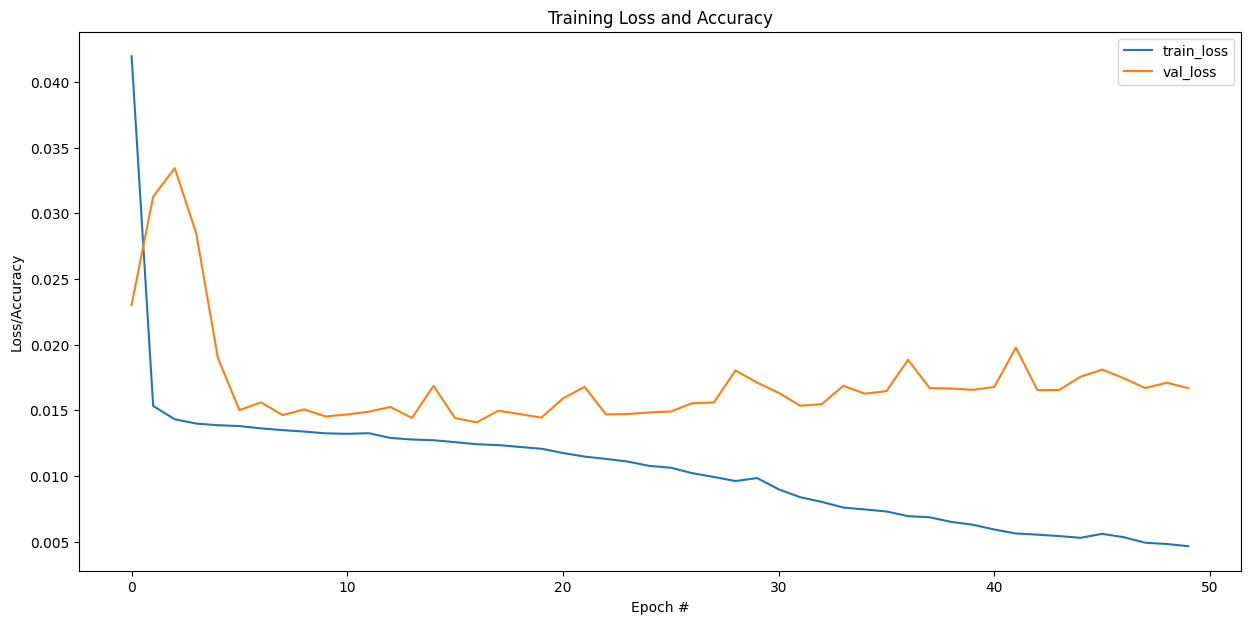

In [29]:
print("[INFO] making predictions...")
decoded = auto_encoder.predict(val_x)
vis = visualize_predictions(decoded, val_x)
image_example_path = "reconstruction"
cv2.imwrite(os.path.join(image_example_path,"recon_vis_100_subclass.png"), vis)
N = np.arange(0, EPOCHS)
plt.figure(figsize=(15,7))
plt.plot(N, H.history["loss"], label="train_loss")
plt.plot(N, H.history["val_loss"], label="val_loss")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

In [30]:
with open('training_1_100_subclass.json', 'w') as f:
    json.dump(H.history, f)

In [31]:
auto_encoder.save('training_1_100_subclass.h5')